# Attrition Rate Analysis


## 1. Introduction

### Dataset Information-
  - Employee Attrition Rate Dataset 
  - 1470 rows, 13 columns
  - Sourced from Kaggle - https://www.kaggle.com/datasets/prachi13/employeeattritionrate?resource=download![image.png](attachment:image.png)
  
### Data Description-
  - Age : Employee Age
  - Attrition : Status of Attrition(Yes or No)
  - Department : Department the employee worked in.
  - DistanceFromHome : Distance from employee home to office
  - Education : Level of the degree the employee completed(1-Below College,2-College,3-Bachelor,4-Master,5-Doctor)
  - EducationField : Employee Field of Study
  - EnvironmentSatisfaction : Satisfaction Levels of the employee on work environment(1-Low,2-Medium,3-High,4-Very High)
  - JobSatisfaction : Satisfaction Levels of the employee on the work assigned(1-Low,2-Medium,3-High,4-Very High)
  - MaritalStatus : Marital Status of the employee
  - MonthlyIncome : Monthly Income of the employee
  - NumCompaniesWorked : Number of companies worked at prior to working at the current company
  - WorkLifeBalance : Employee Rating on Work Life Balance(1-Bad,2-Good,3-Better,4-Best)
  - YearsatCompany : Years of service at the current company
  
### Research Objective and Goals - 	
#### 1) Explore attrition data	
To perform analysis and identify trends and patterns	
To understand what variables are contributing significantly to attrition	
#### 2) Analysis based on groups	
To group employees based on variables and analyse attrition (Ex : Attrition rate based on seniority level of the employees)		

### EDA Hypotheses
I'm particularly interested in this dataset as Employee Attrition rate has significantly increased in the recent years, and I want to understand what factors are contributing significantly to attrition.

### Conceptualized Questions for Analysis
- How DistanceFromHome is influencing the Attrition?
- How is the number of years at the current company related with the attrition rate?
- Which department has the highest and lowest average monthly income, and how is monthly income correlated with job satisfaction or years at the company?
- Which age group is most likely to quit the company?

## 2. Data Analysis

### 2-1. Importing the libraries necessary for your EDA

In [4]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
warnings.filterwarnings('ignore')

In [6]:
data_attrition = pd.read_excel("Attrition_Data.xlsx")
data_attrition.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [8]:
data_attrition.tail()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
1465,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9
1469,34,No,Research & Development,8,3,Medical,2,3,Married,4404,2,4,4


- Pandas read_excel() function allows us to load the excel file into a dataframe.
- The dataframe has been named as data_attrition.
- data_attrition.head() allows us to view the first five rows of a dataframe.
- data_attrition.tail() allows us to view the last five rows of a dataframe.

### 2-3. Review Data

In [12]:
data_attrition.shape

(1470, 13)

- "shape" gives the dimensions of a dataset
- From the above result it can be observed that data_attrition has 1470 rows and 13 columns.

In [15]:
data_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


- "info" method prints the datatypes of the attributes and the non null counts.
- data_attrition has no null values as non-null count = no.of rows in dataset.
- data_attrition has 4 object columns and 9 numeric columns

In [18]:
data_attrition.dtypes

Age                         int64
Attrition                  object
Department                 object
DistanceFromHome            int64
Education                   int64
EducationField             object
EnvironmentSatisfaction     int64
JobSatisfaction             int64
MaritalStatus              object
MonthlyIncome               int64
NumCompaniesWorked          int64
WorkLifeBalance             int64
YearsAtCompany              int64
dtype: object

- "dtypes" has similar functionality to "info" i.e it prints datatypes but doesn't print the non null counts.

Inference from looking at the data types of the attributes - 
- Categorical columns can also be represented as numbers. 
- For instance, Education is a Categorical(Nominal Qualitative Variable) because it is represented as 1-Below College,2-College,3-Bachelor,4-Master,5-Doctor. However, in the dataset it is represented as 1,2,3,4,5. So,its datatype is integer.
- Final understanding is that a categorical column need not necessarily be of object datatype.

In [22]:
#Columns with dtype int
data_attrition.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.728571,6502.931293,2.693197,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.102846,4707.956783,2.498009,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,4.000000,8379.000000,4.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,40.000000


In [24]:
#Categorical Columns
data_attrition[['Attrition','Department','EducationField','MaritalStatus']].describe()

,Attrition,Department,EducationField,MaritalStatus
count,1470,1470,1470,1470
unique,2,3,6,3
top,No,Research & Development,Life Sciences,Married
freq,1233,961,606,673


- "describe" method prints the descriptive statistics.
-  By default it prints summary statistics(mean,std,percentiles,max,min,count) for quantitative columns.
-  prints count, no.of unique values, top(most common value), freq(frequency of the most common value) for categorical  columns.

### 2-4. Generate Sub-dataset

Generating a sub-dataset by dropping Environment Satisfaction from the original dataset. This is because it is similar by defintion to Job Satisfaction column and the summary statistics of both the columns are almost same.

In [29]:
#Sub Dataset
data_updated_attrition = data_attrition.drop(columns=['EnvironmentSatisfaction'])
data_updated_attrition.columns

Index(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')

- "drop" removes rows or columns from the dataset.
- "columns" prints all the column values in the dataset.It can be observed that EnvironmentSatisfaction column is no longer present in the dataset.
-  **data_updated_attrition** is the new subset created from the original dataset.

Renaming Columns Age, YearsAtCompany, NumCompaniesWorked, Attrition

In [33]:
#Rename columns
data_updated_attrition = data_updated_attrition.rename(columns={"Age": "Employee_Age", "YearsAtCompany": "Years_in_Company",
                               "NumCompaniesWorked":"Total_Companies", "Attrition":"Attrition_Status"})
data_updated_attrition.columns

Index(['Employee_Age', 'Attrition_Status', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'Total_Companies', 'WorkLifeBalance',
       'Years_in_Company'],
      dtype='object')

- "rename" allows ua to rename column values.
- It can be observed from the column names result above that Age, YearsAtCompany, NumCompanies worked,Attrition are no longer present and have been replaced with the new column names specified.

In [36]:
#Null values
data_updated_attrition.isnull().sum()

Employee_Age        0
Attrition_Status    0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
JobSatisfaction     0
MaritalStatus       0
MonthlyIncome       0
Total_Companies     0
WorkLifeBalance     0
Years_in_Company    0
dtype: int64

- "isnull" checks for null values in the dataframe.
- "sum" returns the sum of the values, here sums the no.of null values in each column.
-  From the result, it can be observed that there are no null values present in the dataset.

In [39]:
data_updated_attrition.duplicated().sum()

0

- ".duplicated().sum()" prints the total no.of duplicated rows in the dataframe.
- From the result, it can be observed that there are no duplicate values in the dataframe.

### 2-5. Checking Outliers

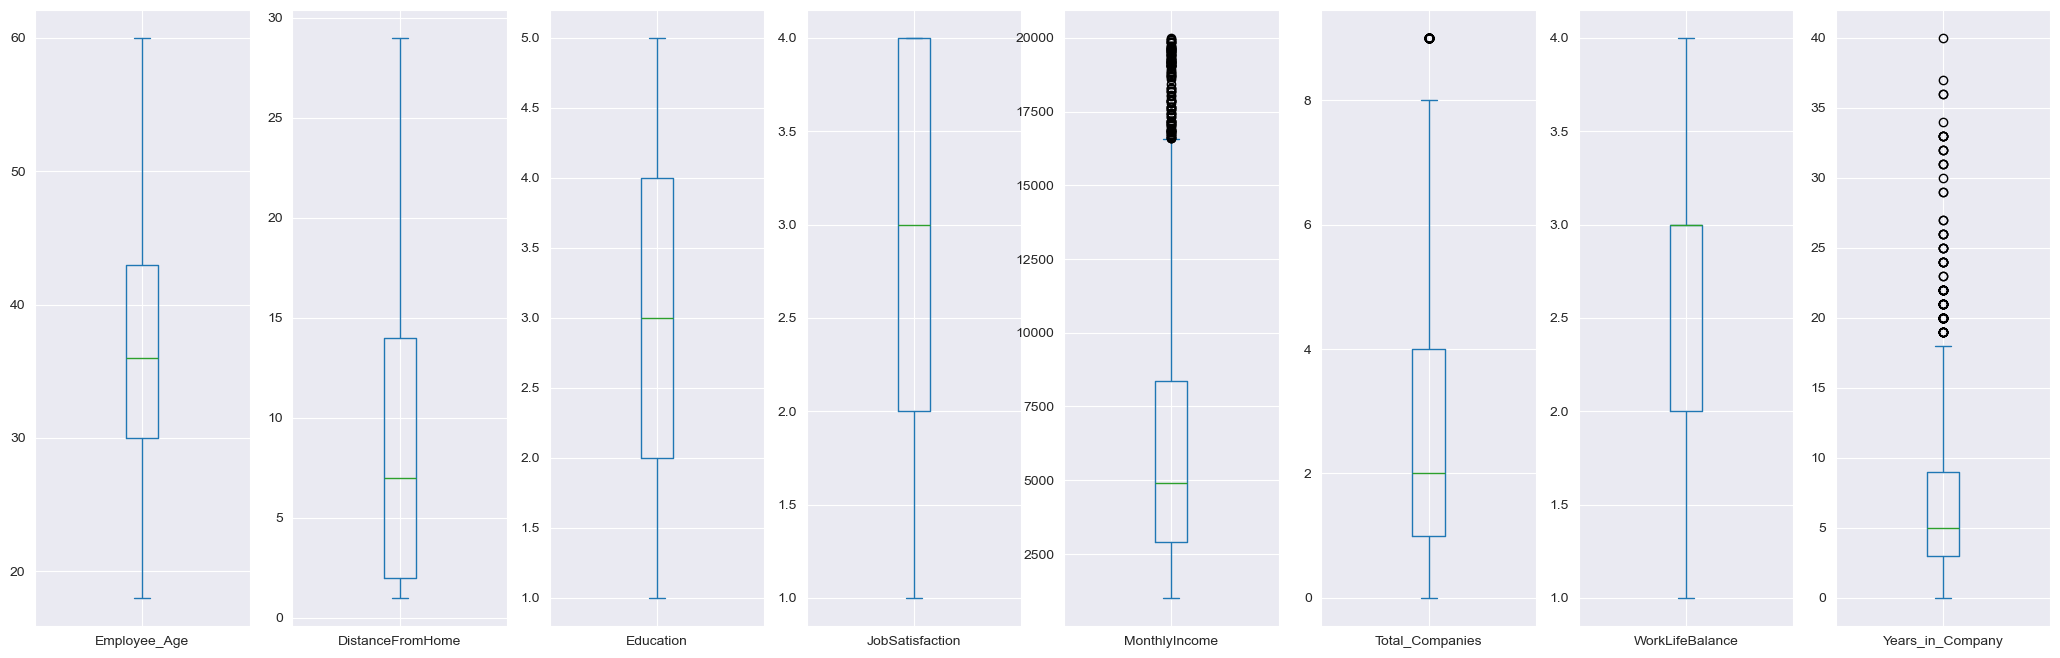

In [43]:
#Outliers for integer columns
data_updated_attrition.plot(kind='box', subplots=True, grid = True, sharey=False, figsize=(26, 8))
plt.show()

- The matplotlib plot function allows us to plot different kinds of plots.
- The Box plot is a useful plot to visualize outliers.

It can be observed that MonthlyIncome, Total_Companies, Years_in_Company has outliers.

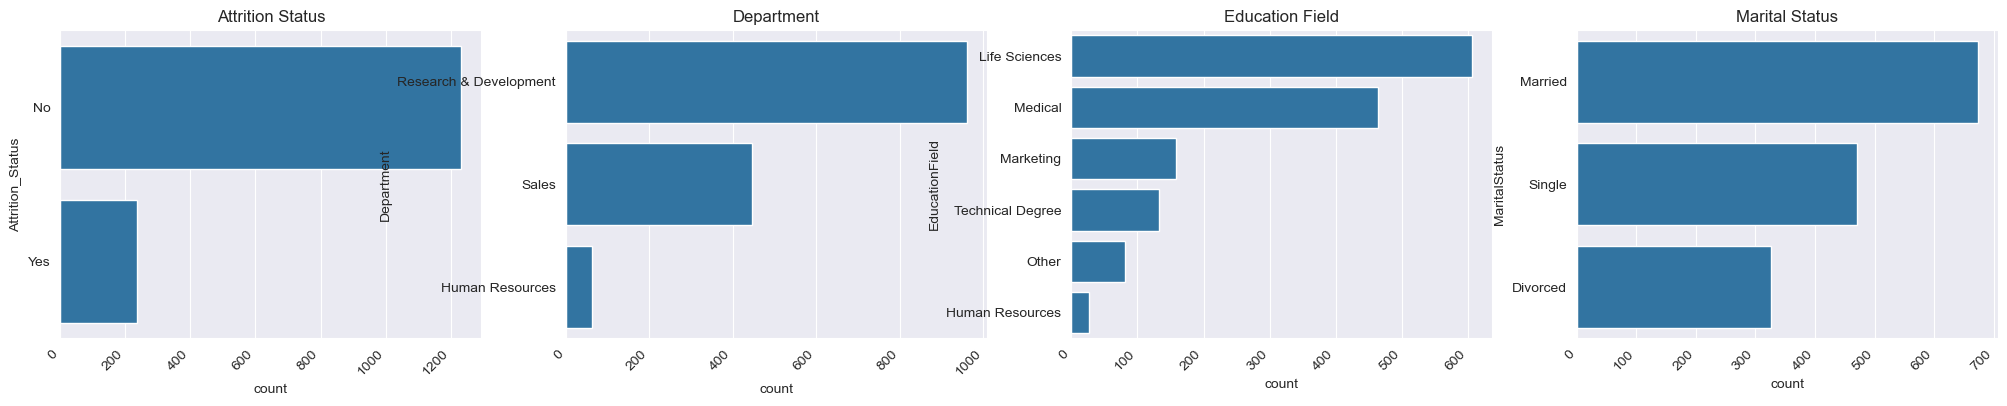

In [47]:
#Countplots for categorical columns.
fig, ax =plt.subplots(1,4,figsize=(25, 4))
sns.countplot(data_updated_attrition['Attrition_Status'], ax=ax[0],order=data_updated_attrition['Attrition_Status'].value_counts().index)
sns.countplot(data_updated_attrition['Department'], ax=ax[1],order=data_updated_attrition['Department'].value_counts().index)
sns.countplot(data_updated_attrition['EducationField'], ax=ax[2],order=data_updated_attrition['EducationField'].value_counts().index)
sns.countplot(data_updated_attrition['MaritalStatus'], ax=ax[3],order=data_updated_attrition['MaritalStatus'].value_counts().index)
ax[0].set_title('Attrition Status')
ax[1].set_title('Department')
ax[2].set_title('Education Field')
ax[3].set_title('Marital Status')
for i in ax:
    i.set_xticklabels(i.get_xticklabels(), rotation=45, horizontalalignment='right')
fig.show()

- The matplotlib subplots allows to plot multiple graphs side by side.
- Countplot shows the counts of observations in each categorical bin using bars.

From the countplots it can be observed that for all columns, there is a significant difference between each value.

### 2-6. Generating Plot(s)

**1) How DistanceFromHome is influencing the Attrition?**

In [53]:
dist_attrition = data_updated_attrition.groupby("Attrition_Status")["DistanceFromHome"].mean()
dist_attrition

Attrition_Status
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

- "groupby" is used to split the data into groups based on some columns
- It can be observed that the avg distance from home for employees who left the company is higher than that of employees who haven't.

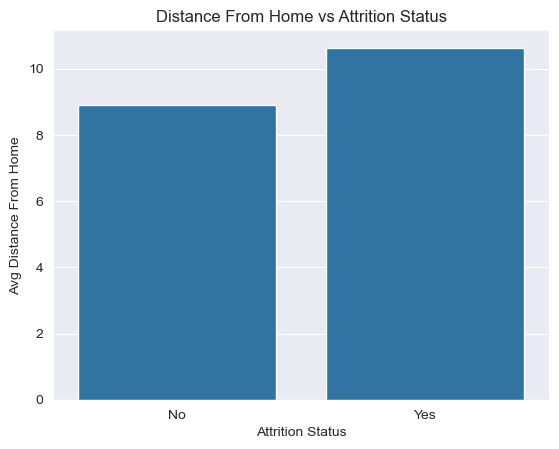

In [56]:
sns.barplot(x=dist_attrition.index, y=dist_attrition.values)
plt.xlabel("Attrition Status")
plt.ylabel("Avg Distance From Home")
plt.title("Distance From Home vs Attrition Status")
plt.show()

- A bar plot describes the comparisons between the discrete categories

**2) How is the number of years at the current company related with the attrition rate?**

Attrition_Status
No     7.369019
Yes    5.130802
Name: Years_in_Company, dtype: float64


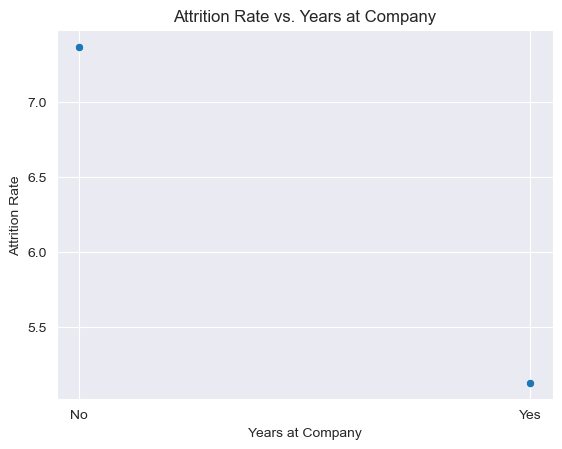

In [60]:
attrition_rate = data_updated_attrition.groupby('Attrition_Status')['Years_in_Company'].mean()
print(attrition_rate)

sns.scatterplot(x=attrition_rate.index, y=attrition_rate.values)
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate vs. Years at Company")
plt.show()

- Scatter plot is used to represent relationship between two different values, this can be acheived through ".scatterplot()"
- From the plot it can be inferred that employee who spent less years at the company has left than the employees who spent more years.

**3) Which department has the highest and lowest average monthly income, and how is monthly income correlated with job satisfaction or years at the company?**

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64


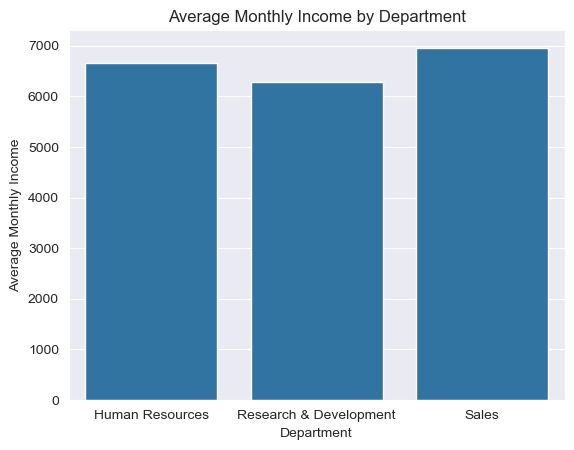

In [64]:
avg_income_by_department = data_updated_attrition.groupby("Department")["MonthlyIncome"].mean()
print(avg_income_by_department)

sns.barplot(x=avg_income_by_department.index, y=avg_income_by_department.values)
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.title("Average Monthly Income by Department")
plt.show()

From the plot it can be inferred that Sales Department employees have higher average monthly income.

                  MonthlyIncome  JobSatisfaction  Years_in_Company
MonthlyIncome          1.000000        -0.007157          0.514285
JobSatisfaction       -0.007157         1.000000         -0.003803
Years_in_Company       0.514285        -0.003803          1.000000


<Axes: >

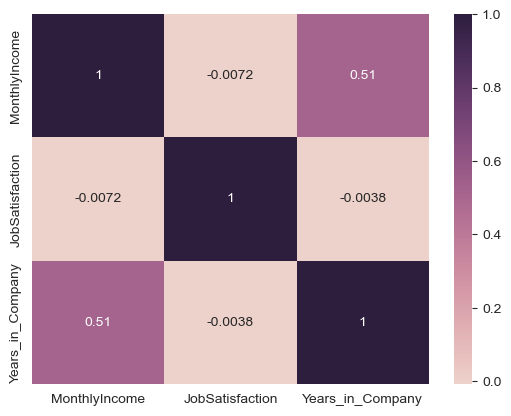

In [67]:
correlation_matrix = data_updated_attrition[["MonthlyIncome", "JobSatisfaction", "Years_in_Company"]].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix,annot=True,cmap=sns.cubehelix_palette(as_cmap=True))

- As expected,Monthly income is highly correlated with years at the company, generally as you work for longer years your income increases.
- Job satisfaction and monthly income are negatively correlated, this can be interpreted as even though income is high the employee might not be happy with the work being done or the work environment.

**4) Which age group is most likely to quit the company?**

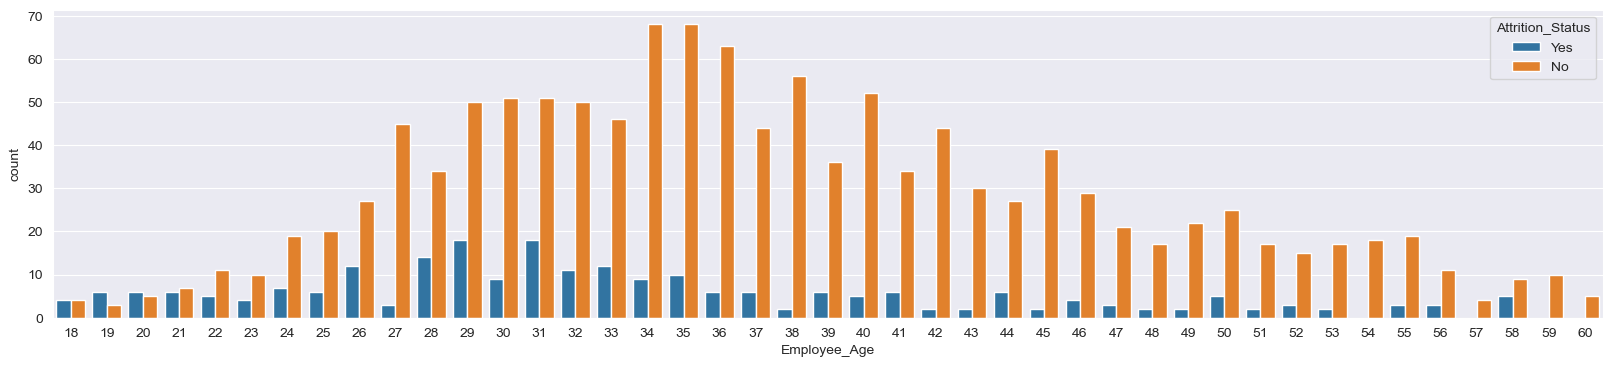

In [71]:
plt.subplots(figsize=(20,4))
sns.countplot(x='Employee_Age',  hue='Attrition_Status', data= data_updated_attrition)
plt.show()

- From the graph it can be inferred that there are higher number of employees with age 34 and 35.
- It can be observed that as the age of employee increased, attrition rate decreased, this might be because the employee might be in a higher position in the company and is satisfied with the job.
- Employees in the age group 24 - 35 are more likely to quit the company.Considering career aspirations(to pursue higher education or switch to different fields etc.), constant urge to try different things this numbers aren't surprising.

## 3. EDA

Performing EDA - insights generated from the following analysis has been documented under Summary.

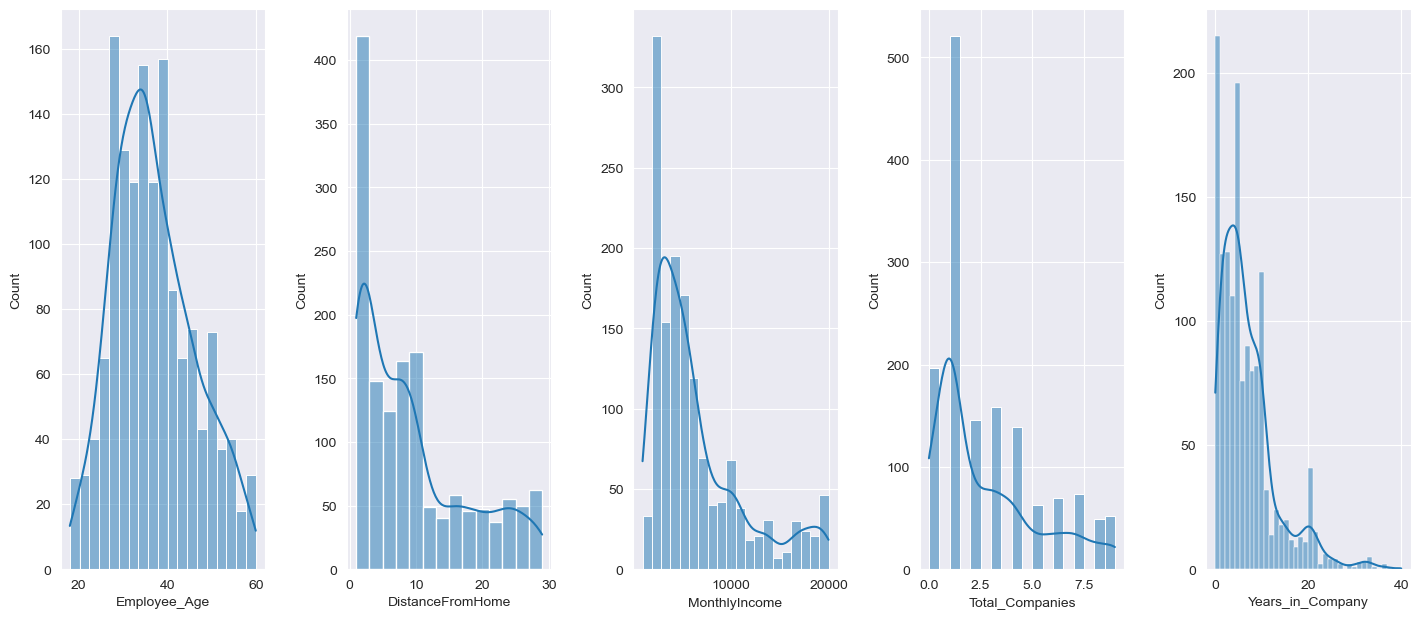

In [76]:
fig, axs = plt.subplots(1,5, figsize=(15, 7))

sns.histplot(data=data_updated_attrition, x="Employee_Age", kde=True, ax=axs[0])
sns.histplot(data=data_updated_attrition, x="DistanceFromHome", kde=True, ax=axs[1])
sns.histplot(data=data_updated_attrition, x="MonthlyIncome", kde=True,  ax=axs[2])
sns.histplot(data=data_updated_attrition, x="Total_Companies", kde=True, ax=axs[3])
sns.histplot(data=data_updated_attrition, x="Years_in_Company", kde=True, ax=axs[4])

plt.subplots_adjust(left=1, right=1.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.4) 
plt.show()

A histogram is a classic visualization tool that represents the distribution of one or more variables by counting the number of observations that fall within discrete bins. This can be achieved through histplot.

In [81]:
attrition_counts = data_updated_attrition['Attrition_Status'].value_counts()
attrition_counts

Attrition_Status
No     1233
Yes     237
Name: count, dtype: int64

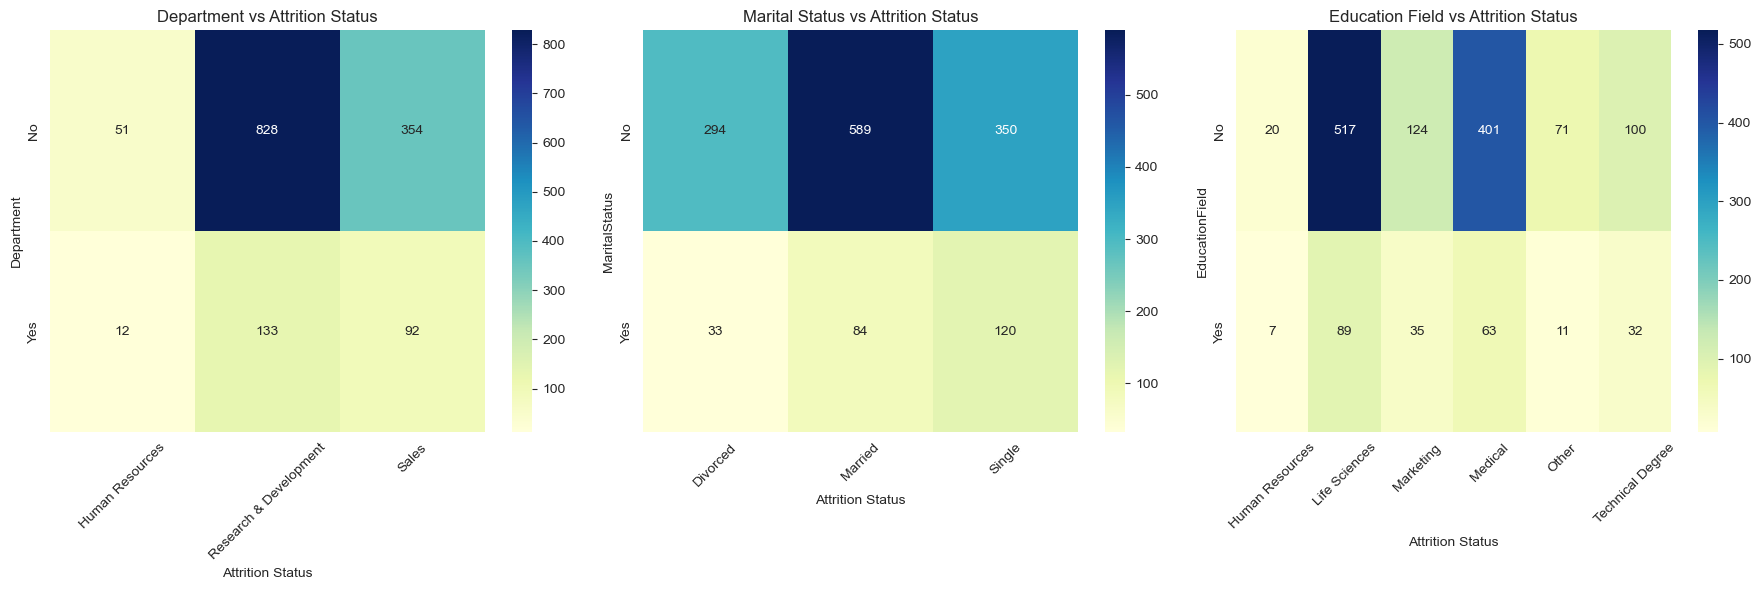

In [83]:
categorical = ['Department', 'MaritalStatus', 'EducationField']
titles = ['Department vs Attrition Status', 'Marital Status vs Attrition Status', 'Education Field vs Attrition Status']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, var in enumerate(categorical):
    cross_tab = pd.crosstab(data_updated_attrition['Attrition_Status'], data_updated_attrition[var])
    sns.heatmap(cross_tab, annot=True, cmap="YlGnBu", fmt="d", ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Attrition Status')
    axes[i].set_ylabel(var)
    axes[i].set_xticklabels(axes[i].get_xticklabels(),rotation=45)

plt.tight_layout()
plt.show()

The crosstab method computes frequency table of the factors. In our case it is used to find frequency between categorical variables.

Are employees who have been with the company for a longer time more satisfied with their jobs and work-life balance?

                  WorkLifeBalance  JobSatisfaction  Years_in_Company
WorkLifeBalance          1.000000        -0.019459          0.012089
JobSatisfaction         -0.019459         1.000000         -0.003803
Years_in_Company         0.012089        -0.003803          1.000000


<Axes: >

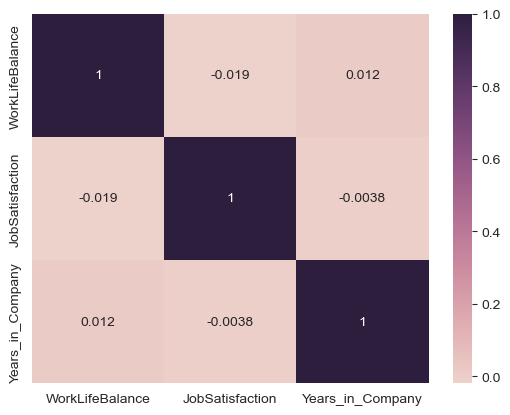

In [87]:
correlation_matrix = data_updated_attrition[["WorkLifeBalance", "JobSatisfaction", "Years_in_Company"]].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix,annot=True,cmap=sns.cubehelix_palette(as_cmap=True))

In [89]:
data_updated_attrition['EmployeeID'] = range(1, len(data_updated_attrition) + 1)
data_updated_attrition.insert(0, 'EmployeeID', data_updated_attrition.pop('EmployeeID'))
data_updated_attrition.head()

,EmployeeID,Employee_Age,Attrition_Status,Department,DistanceFromHome,Education,EducationField,JobSatisfaction,MaritalStatus,MonthlyIncome,Total_Companies,WorkLifeBalance,Years_in_Company
0,1,41,Yes,Sales,1,2,Life Sciences,4,Single,5993,8,1,6
1,2,49,No,Research & Development,8,1,Life Sciences,2,Married,5130,1,3,10
2,3,37,Yes,Research & Development,2,2,Other,3,Single,2090,6,3,0
3,4,33,No,Research & Development,3,4,Life Sciences,3,Married,2909,1,3,8
4,5,27,No,Research & Development,2,1,Medical,2,Married,3468,9,3,2


In [91]:
#Using One Hot encoding to convert education field into numerical values
df_education = pd.get_dummies(data_updated_attrition[['EducationField','EmployeeID']], columns=['EducationField'])
df_education.head()

,EmployeeID,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,1,False,True,False,False,False,False
1,2,False,True,False,False,False,False
2,3,False,False,False,False,True,False
3,4,False,True,False,False,False,False
4,5,False,False,False,True,False,False


In [93]:
#Joining the dummies generated dataset with the original dataset.
data_updated_attrition = pd.merge(data_updated_attrition, df_education, on="EmployeeID", how="inner")
data_updated_attrition.head()

,EmployeeID,Employee_Age,Attrition_Status,Department,DistanceFromHome,Education,EducationField,JobSatisfaction,MaritalStatus,MonthlyIncome,Total_Companies,WorkLifeBalance,Years_in_Company,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,1,41,Yes,Sales,1,2,Life Sciences,4,Single,5993,8,1,6,False,True,False,False,False,False
1,2,49,No,Research & Development,8,1,Life Sciences,2,Married,5130,1,3,10,False,True,False,False,False,False
2,3,37,Yes,Research & Development,2,2,Other,3,Single,2090,6,3,0,False,False,False,False,True,False
3,4,33,No,Research & Development,3,4,Life Sciences,3,Married,2909,1,3,8,False,True,False,False,False,False
4,5,27,No,Research & Development,2,1,Medical,2,Married,3468,9,3,2,False,False,False,True,False,False


merge function allows to join multiple tables on various kinds of joins.

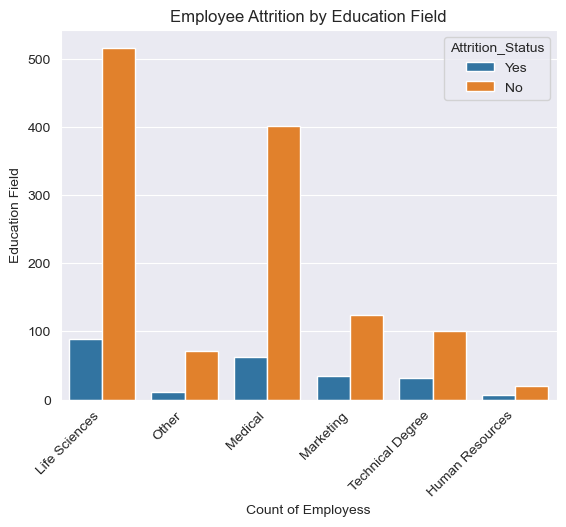

In [96]:
ax = sns.countplot(data=data_updated_attrition, x='EducationField', hue='Attrition_Status')
plt.xlabel("Count of Employess")
plt.ylabel("Education Field")
plt.title("Employee Attrition by Education Field")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

In [98]:
edu_map = {1:'Below_College',2:'College',3:'Bachelor',4:'Master',5:'Doctor'}
data_updated_attrition['Education_Map'] = data_updated_attrition['Education'].map(edu_map)
data_updated_attrition.head()

,EmployeeID,Employee_Age,Attrition_Status,Department,DistanceFromHome,Education,EducationField,JobSatisfaction,MaritalStatus,MonthlyIncome,Total_Companies,WorkLifeBalance,Years_in_Company,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Education_Map
0,1,41,Yes,Sales,1,2,Life Sciences,4,Single,5993,8,1,6,False,True,False,False,False,False,College
1,2,49,No,Research & Development,8,1,Life Sciences,2,Married,5130,1,3,10,False,True,False,False,False,False,Below_College
2,3,37,Yes,Research & Development,2,2,Other,3,Single,2090,6,3,0,False,False,False,False,True,False,College
3,4,33,No,Research & Development,3,4,Life Sciences,3,Married,2909,1,3,8,False,True,False,False,False,False,Master
4,5,27,No,Research & Development,2,1,Medical,2,Married,3468,9,3,2,False,False,False,True,False,False,Below_College


In [100]:
avg_income = data_updated_attrition.groupby("Education_Map")["MonthlyIncome"].mean()
avg_income

Education_Map
Bachelor         6517.263986
Below_College    5640.570588
College          6226.645390
Doctor           8277.645833
Master           6832.402010
Name: MonthlyIncome, dtype: float64

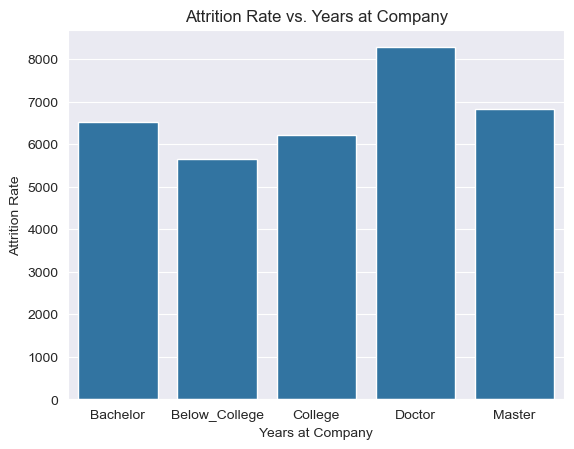

In [102]:
sns.barplot(x=avg_income.index, y=avg_income.values)
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate vs. Years at Company")
plt.show()

In [104]:
avg_income_attr = data_updated_attrition.groupby("Attrition_Status")["MonthlyIncome"].mean()
avg_income_attr

Attrition_Status
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

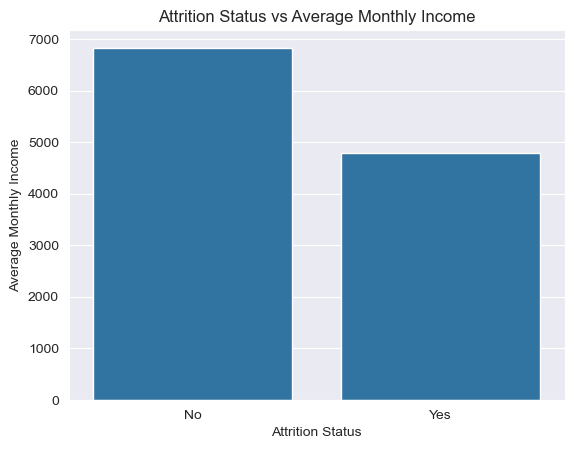

In [106]:
sns.barplot(x=avg_income_attr.index, y=avg_income_attr.values)
plt.xlabel("Attrition Status")
plt.ylabel("Average Monthly Income")
plt.title("Attrition Status vs Average Monthly Income")
plt.show()

## 4. Conclusion 

1) How DistanceFromHome is influencing the Attrition?
- Employees who have left the company had an average commute of 10.63 miles, compared to 8.9 miles for those who have stayed. Despite the difference between the two averages, attrition cannot be entirely attributed to the distance factor due to small difference between them.

2) How is the number of years at the current company related with the attrition rate?
- The average years spent by an employee who left the company is 5, while the ones who stayed have an average of 7 years. It implies that employees who tend to leave have shorter span. However, even this can't be the sole factor for attrition as there isn't much difference between the two.

3) Which department has the highest and lowest average monthly income, and how is monthly income correlated with job satisfaction or years at the company?
- Sales Department has higher average monthly income followed by Human Resources and Research & Development. The difference between the 3 salaries however isn't significant. For Sales - 6959, Human Resources - 6654 and Research & Development - 6281.
- As expected,Monthly income is highly correlated with years at the company, generally as you work for longer years your income increases.
- Job satisfaction and monthly income are negatively correlated, this can be interpreted as even though income is high the employee might not be happy with the work being done or the work environment.

4) Which age group is most likely to quit the company?
- From the plot, it can be observed that as the age of employee increased, attrition rate decreased, this might be because the employee might be in a higher position in the company and is satisfied with the job.
- Employees in the age group 24 - 35 are more likely to quit the company.Considering career aspirations(to pursue higher education or switch to different fields etc.), constant urge to try different things this numbers aren't surprising.

## 5. Summary

1) Learnings 
- The analysis helped understand dealing with both categorical and numerical attributes, using different methods to manipulate and transform the dataset, understanding the different plots that can be used for different problems etc.,

2) Insights
- Observed that Employee Age and Number of years in the current company is positively correlated with monthly income.
- People working in the Research & Development Department had significantly less attrition compared to other departments.
- Employees whose marital status is single are more likely to leave the company(25%) than those who were married or single.
- Surprisingly, years in the current company and job satisfaction are negatively correlated and there isn't much correlation.
- Also, work life balance has almost no correlation with years in the company.
- Employee with a doctorate degree is likely to earn more than employee with other degrees.
- Employees with a bachelor,master,college,below college level earned almost the same amount.
- Employee who quit the company has a lower salary level on average than the employee who decided to stay.

3) Future Work
- Further a predictive model can be trained to identify if an employee is likely to quit or not. 
- Better analysis can be done on the dataset if there are features like Gender and job title of the employee. 
- The dataset has less number of records for Attrition = 'Yes' making the data highly imbalanced, better and meaningful results can be obtained if there are enough records. Looking forward to working on such datasets.

4) References
- https://pandas.pydata.org/docs/reference/frame.html
- https://seaborn.pydata.org/api.html
- https://matplotlib.org/stable/gallery/index.html
- https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15
- https://www.kaggle.com/datasets/prachi13/employeeattritionrate?resource=download